# The Meaning of P

When performing feature selection, we often estimate the significance of a feature by its **p-value**. For example, we determined the values of a set of factors in a linear model (see image below). 

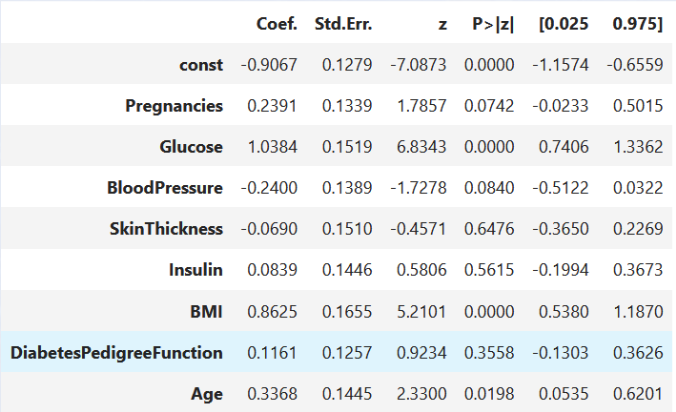

Next, we take a look at the p-value (here $P>|z|$) and then say, only features for which the p-value of the coeficient is below 0.01, are significant (for example "Glucose", but not "Insulin").<br>
The definition of a p-value:<br> 
<br>
*"The probability to get such a result, or more extreme, given the null hypothesis is true"*<br> 
<br>
is rather simple, but the interpretation is tricky.<br>
In this session we want to deepen the understanding for the meaning of a p-value.

<br>

## 0) Importing Libraries 

First, we need to import our standard libraries for plotting and numerical operations:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Next, we import libraries required for running some statistical tests.

In [2]:
from scipy import stats
from statsmodels.stats.rates import test_poisson

<br>

# 1) The p-value

The standard workflow is the following:<br>
- you run a statistical test
- this test returns a p-value
- if the p-value is below a certain value, say $\alpha = 0.01$, then the test is regarded significant

For example, we want to compare two samples A and B, which - in order to keep the example simple - we generate via random, normally distributed numbers with the same mean and the same variance:

In [3]:
mu   = 0
sig1 = 1
sig2 = 3
N1   = 50 # size sample A  
N2   = 80 # size sample B

In [4]:
np.random.seed(43) # make results comparable

In [5]:
sampleA, sampleB = np.random.normal(mu, sig1, (N1,),), np.random.normal(mu, sig2, (N2,))

Both samples vary, because they have been generated randomly, but they have been sampled from the same distribution. Let's plot them first: 

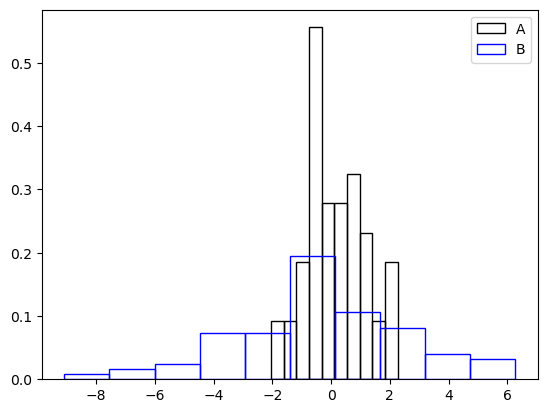

In [6]:
plt.hist(sampleA, label = 'A', fill = False, density=True)
plt.hist(sampleB, label = 'B', fill = False, density=True, edgecolor = 'blue')
plt.legend()

You might want to test, if both samples have been generated from two distributions with the same mean $\mu$. In such a case:<br>
<br>
- normally distributed data<br>
- testing for the mean $\mu$, **not** for the variances $\sigma^2$<br>
<br>
you run a so-called **t-test**. The null hypothesis $H_0$ is $\mu_A = \mu_B$, i.e. both samples have been drawn from the a normal distribution with the same mean.<br>  

Let's run the actual t-test:

In [7]:
_, p_value = stats.ttest_ind(sampleA, sampleB, equal_var = False)
print("p-value:", p_value)

p-value: 0.13400914416804902


The p-value should be greater than $\alpha$, hence $H_0$ is **accepted** and the conclusion is that both samples had been drawn from a normal distribution of the same mean.

<br>

# 2) Exercise

## 2.1) Real Data

In an experiment, the normalized body weigth of genetically modified mice ("KO") was compared to the body weight of healthy ("WT") mice. 

In [8]:
WT = np.array([0.9110807, 1.088919, 1.03329, 0.9699879, 0.9593626, 1.03736, 0.9779246, 0.9400842, 1.030455, 1.051536, 1.183377, 0.9613777, 0.8552451, 1.203522, 1.023505, 1.02235, 0.7506234, 1.133319, 0.945626, 0.9210547])
KO = np.array([0.6693618, 0.7789116, 0.7524274, 0.6443067, 1.140946, 0.9826416, 0.6675799, 0.6960907, 0.8166829, 0.616216, 0.8859794, 0.5354687, 0.6553164, 0.7481211, 0.7616847, 0.8392595, 0.9440662, 0.8502076])

- write a small function **t_Test** using ```def``` that runs a t-test on the data and returns the p-value as output and as print statement. What is the result?<br>
- plot a histogram of the two samples like the one above<br>
- according to its definition: what is the largest and what is the smallest value of a p-value possible? 

In [9]:
def t_Test(sampleA: np.array, sampleB: np.array, prt = None):

    _, p_value = stats.ttest_ind(sampleA, sampleB, equal_var = False)

    #print("t-statistic:", t_stat)
    if prt:
        print("p-value:", p_value)
    
    return p_value

In [10]:
p_value = t_Test(WT, KO, prt = 'yes')

p-value: 1.0245021990384397e-05


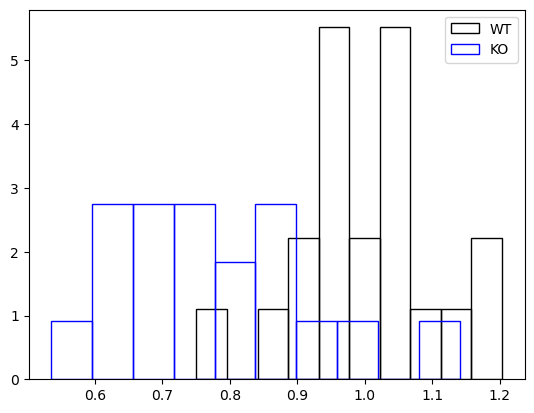

In [11]:
plt.hist(WT, label = 'WT', fill = False, density=True)
plt.hist(KO, label = 'KO', fill = False, density=True, edgecolor = 'blue')
plt.legend()

The largest possible value is 1 and the smallest value is zero, because the p-value is a probability.

<br>

## 2.2) How does the p-value change if we change $\mu$ and $\sigma$?

In order to understand how the p-value changes if the samples are different, generate two samples A and B like in Section 1, but now:<br>
- change $\mu$ of one sample, say sample B, and run the t-test for a set of five different values for $\mu_B$<br>
- set $\mu_A = \mu_B$ and run the t-test for a set of five different variances for $\sigma^2_B$<br>
- print the p-values each time. How do they change?

In [ ]:
"""your code here"""